In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata

warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

df = pd.read_csv('Nacimientos_2024.csv')
print(f"Dataset cargado: {df.shape}")

Dataset cargado: (1413203, 64)


In [ ]:
def normalizar_columna(texto):
    """Elimina tildes y caracteres especiales"""
    # Normalizar unicode
    texto = unicodedata.normalize('NFD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')

    texto = texto.upper().replace(' ', '_')
    return texto

df.columns = [normalizar_columna(col) for col in df.columns]
print("Columnas normalizadas:")
print(list(df.columns))

Columnas normalizadas:
['NACIOEXTRANJERO', 'ENTIDADNACIMIENTO', 'MUNICIPIONACIMIENTO', 'EDAD', 'SECONSIDERAINDIGENA', 'HABLALENGUAINDIGENA', 'FECHANACIMIENTOMADRE', 'ESTADOCONYUGAL', 'RESIDEEXTRANJERO', 'ENTIDADRESIDENCIA', 'MUNICIPIORESIDENCIA', 'LOCALIDADRESIDENCIA', 'NUMEROEMBARAZOS', 'HIJOSNACIDOSMUERTOS', 'HIJOSNACIDOSVIVOS', 'HIJOSSOBREVIVIENTES', 'CONDICIONHIJOANTERIOR', 'VIVEHIJOANTERIOR', 'ORDENNACIMIENTO', 'ATENCIONPRENATAL', 'TRIMESTREPRIMERCONSULTA', 'TOTALCONSULTAS', 'SOBREVIVIOPARTO', 'AFILIACION', 'ESCOLARIDAD', 'INTERRUMPIOESTUDIOS', 'CLAVEOCUPACIONHABITUAL', 'TRABAJAACTUALMENTE', 'EDADPADRE', 'FECHANACIMIENTO', 'HORANACIMIENTO', 'SEXO', 'EDADGESTACIONAL', 'TALLA', 'PESO', 'APGAR', 'SILVERMAN', 'TAMIZAUDITIVO', 'VACUNA_BCG', 'VACUNAHEPATITIS_B', 'VITAMINA_A', 'VITAMINA_K', 'PRODUCTOEMBARAZO', 'ORDENPRODUCTO', 'TOTALPRODUCTOS', 'CODIGOCIEANOMALIA1', 'CODIGOCIEANOMALIA2', 'LUGARNACIMIENTO', 'CLUES', 'TIEMPOTRASLADO', 'RESOLUCIONEMBARAZO', 'UTILIZOFORCEPS', 'TIPOCESAREA', 

In [ ]:
variables_usar = [
    'EDAD', 'ESCOLARIDAD', 'TRABAJAACTUALMENTE', 'ESTADOCONYUGAL',
    'NUMEROEMBARAZOS', 'ATENCIONPRENATAL', 'TRIMESTREPRIMERCONSULTA',
    'TOTALCONSULTAS', 'AFILIACION', 'LUGARNACIMIENTO', 
    'PESO', 'TALLA', 'EDADGESTACIONAL', 'SEXO', 'APGAR'
]

# Recrear df_eda solo con las variables originales seleccionadas
df_eda = df[variables_usar].copy()

print(f"Variables seleccionadas: {len(variables_usar)}")
print(f"Registros: {len(df_eda)}")
print(f"Columnas en df_eda: {list(df_eda.columns)}") 


Variables seleccionadas: 15
Registros: 1413203
Columnas en df_eda: ['EDAD', 'ESCOLARIDAD', 'TRABAJAACTUALMENTE', 'ESTADOCONYUGAL', 'NUMEROEMBARAZOS', 'ATENCIONPRENATAL', 'TRIMESTREPRIMERCONSULTA', 'TOTALCONSULTAS', 'AFILIACION', 'LUGARNACIMIENTO', 'PESO', 'TALLA', 'EDADGESTACIONAL', 'SEXO', 'APGAR']


In [ ]:

# Calcular valores faltantes
valores_faltantes = (df_eda.isnull().sum() / len(df_eda) * 100).sort_values(
    ascending=False
)

print("TOP 5 VARIABLES CON MÁS VALORES FALTANTES:")
top_5 = valores_faltantes.head(5)
for var, porcentaje in top_5.items():
    print(f"{var}: {porcentaje:.2f}%")

TOP 5 VARIABLES CON MÁS VALORES FALTANTES:
TOTALCONSULTAS: 0.06%
ESCOLARIDAD: 0.00%
EDAD: 0.00%
ESTADOCONYUGAL: 0.00%
NUMEROEMBARAZOS: 0.00%


In [33]:
variables_numericas = ['PESO', 'TALLA', 'EDADGESTACIONAL', 'EDAD', 'TOTALCONSULTAS', 'APGAR']

estadisticas = pd.DataFrame()

for var in variables_numericas:
    if var in df_eda.columns:
        estadisticas[var] = {
            'Promedio': df_eda[var].mean(),
            'Mediana': df_eda[var].median(),
            'Desv_Estándar': df_eda[var].std()
        }

estadisticas = estadisticas.T

print("\nESTADÍSTICAS DE VARIABLES NUMÉRICAS:")
print(estadisticas.round(2))

print("\nINTERPRETACIÓN:")
print(f"Peso promedio al nacer: {estadisticas.loc['PESO', 'Promedio']:.1f} gramos")
print(f"Edad promedio de madres: {estadisticas.loc['EDAD', 'Promedio']:.1f} años")
print(f"Promedio de consultas prenatales: {estadisticas.loc['TOTALCONSULTAS', 'Promedio']:.1f}")
print(f"APGAR promedio: {estadisticas.loc['APGAR', 'Promedio']:.1f}/10")


ESTADÍSTICAS DE VARIABLES NUMÉRICAS:
                 Promedio  Mediana  Desv_Estándar
PESO              3429.78   3130.0        1562.92
TALLA               49.44     50.0           2.92
EDADGESTACIONAL     38.49     39.0           2.06
EDAD                26.38     26.0           6.43
TOTALCONSULTAS       7.96      8.0           5.21
APGAR                9.33      9.0           6.71

INTERPRETACIÓN:
Peso promedio al nacer: 3429.8 gramos
Edad promedio de madres: 26.4 años
Promedio de consultas prenatales: 8.0
APGAR promedio: 9.3/10


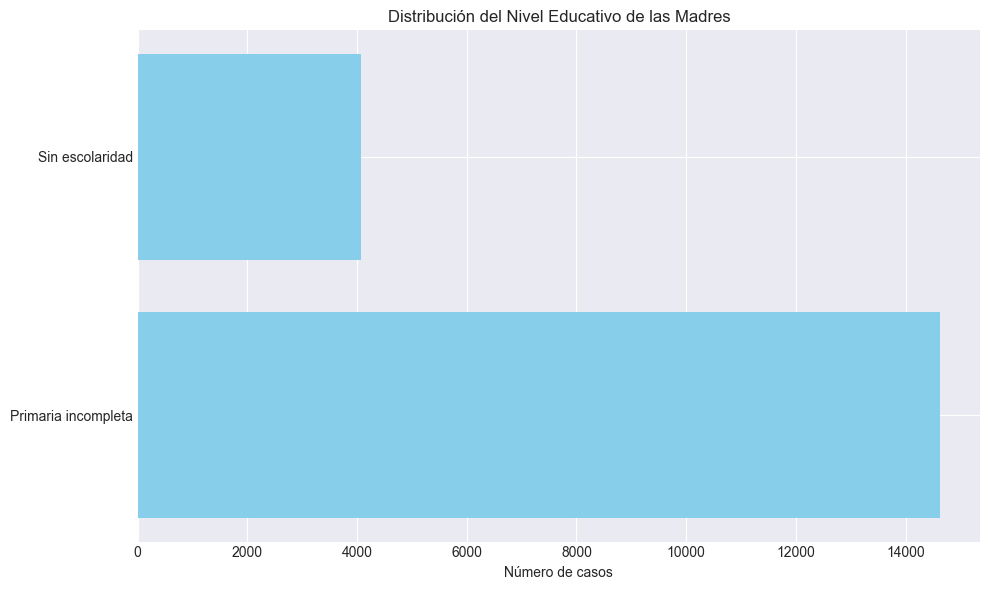

In [ ]:
escolaridad_map = {
    0: 'Sin escolaridad',
    1: 'Primaria incompleta', 
    2: 'Primaria completa',
    3: 'Secundaria incompleta',
    4: 'Secundaria completa',
    5: 'Preparatoria incompleta',
    6: 'Preparatoria completa',
    7: 'Licenciatura incompleta',
    8: 'Licenciatura completa',
    9: 'Posgrado'
}

df_eda['escolaridad_desc'] = df_eda['ESCOLARIDAD'].map(escolaridad_map)

plt.figure(figsize=(10, 6))
escolaridad_counts = df_eda['escolaridad_desc'].value_counts()
plt.barh(escolaridad_counts.index, escolaridad_counts.values, color='skyblue')
plt.xlabel('Número de casos')
plt.title('Distribución del Nivel Educativo de las Madres')
plt.tight_layout()
plt.show()

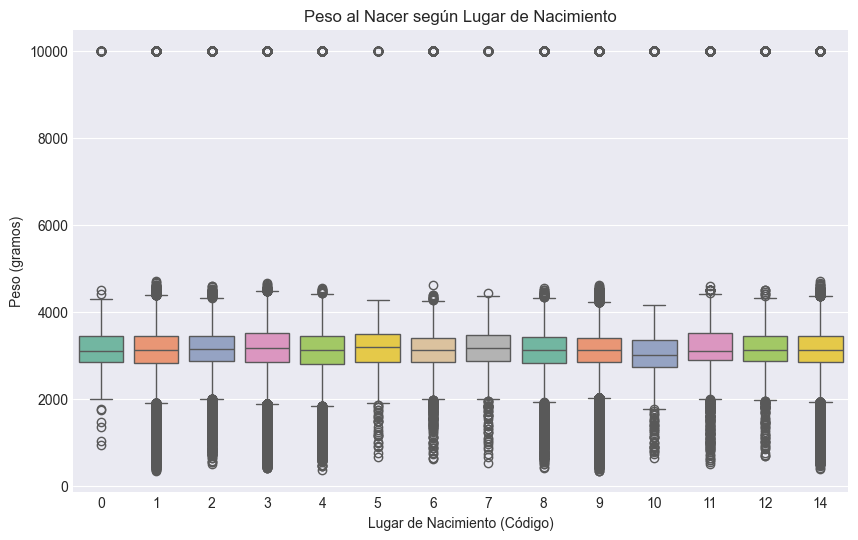

In [ ]:

plt.figure(figsize=(10, 6))
df_temp = df[df['LUGARNACIMIENTO'].notna() & df['PESO'].notna()]
sns.boxplot(data=df_temp, x='LUGARNACIMIENTO', y='PESO', palette='Set2')
plt.xlabel('Lugar de Nacimiento (Código)')
plt.ylabel('Peso (gramos)')
plt.title('Peso al Nacer según Lugar de Nacimiento')
plt.show()

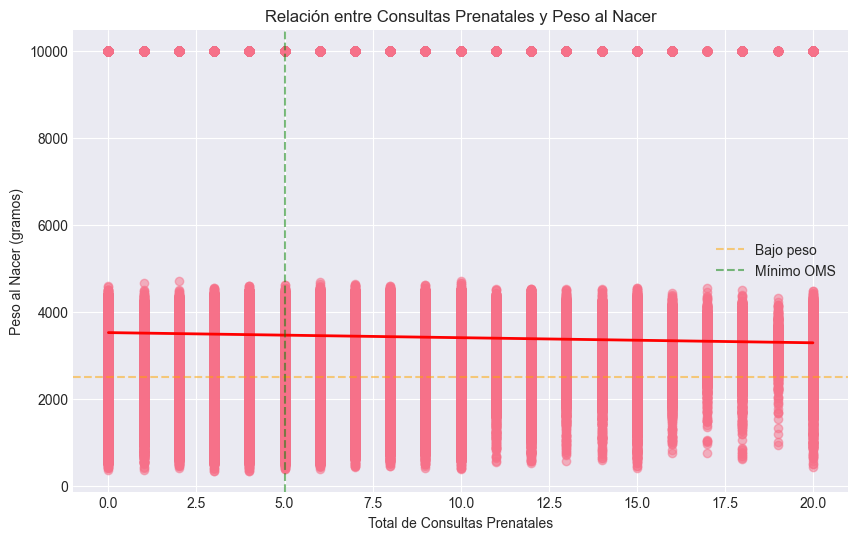

Correlación: -0.0249


In [11]:
# Filtrar datos válidos
df_consultas = df_eda[(df_eda['TOTALCONSULTAS'].notna()) & 
                        (df_eda['PESO'].notna()) &
                        (df_eda['TOTALCONSULTAS'] <= 20)]

plt.figure(figsize=(10, 6))
plt.scatter(df_consultas['TOTALCONSULTAS'], df_consultas['PESO'], alpha=0.5)

z = np.polyfit(df_consultas['TOTALCONSULTAS'], df_consultas['PESO'], 1)
p = np.poly1d(z)
plt.plot(df_consultas['TOTALCONSULTAS'].sort_values(), 
         p(df_consultas['TOTALCONSULTAS'].sort_values()), "r-", linewidth=2)

plt.axhline(y=2500, color='orange', linestyle='--', alpha=0.5, label='Bajo peso')
plt.axvline(x=5, color='green', linestyle='--', alpha=0.5, label='Mínimo OMS')
plt.xlabel('Total de Consultas Prenatales')
plt.ylabel('Peso al Nacer (gramos)')
plt.title('Relación entre Consultas Prenatales y Peso al Nacer')
plt.legend()
plt.show()

# Correlación
correlacion = df_consultas['TOTALCONSULTAS'].corr(df_consultas['PESO'])
print(f"Correlación: {correlacion:.4f}")

In [34]:
# 1. Categoría de peso
def categoria_peso(peso):
    if pd.isna(peso):
        return np.nan
    elif peso < 2500:
        return 'Bajo peso'
    elif peso <= 4000:
        return 'Normal'
    else:
        return 'Alto'

df_eda['categoria_peso'] = df_eda['PESO'].apply(categoria_peso)

# 2. Madre adolescente
df_eda['madre_adolescente'] = (df_eda['EDAD'] < 18).astype(int)

# 3. Atención prenatal adecuada (5+ consultas)
df_eda['atencion_adecuada'] = (df_eda['TOTALCONSULTAS'] >= 5).astype(int)

# 4. Sin derechohabiencia
df_eda['sin_derechohabiencia'] = (df_eda['AFILIACION'] == 0).astype(int)

# 5. Bebé prematuro
df_eda['prematuro'] = (df_eda['EDADGESTACIONAL'] < 37).astype(int)

# Mostrar resultados
print("CARACTERÍSTICAS DERIVADAS GENERADAS:")
print(f"Madres adolescentes: {df_eda['madre_adolescente'].mean()*100:.2f}%")
print(f"Sin derechohabiencia: {df_eda['sin_derechohabiencia'].mean()*100:.2f}%")
print(f"Bebés prematuros: {df_eda['prematuro'].mean()*100:.2f}%")
print(f"Con atención prenatal adecuada: {df_eda['atencion_adecuada'].mean()*100:.2f}%")

CARACTERÍSTICAS DERIVADAS GENERADAS:
Madres adolescentes: 7.12%
Sin derechohabiencia: 8.04%
Bebés prematuros: 8.57%
Con atención prenatal adecuada: 86.69%


In [13]:
# Guardar el dataset limpio y con características derivadas
df_eda.to_csv('nacimientos_procesado.csv', index=False)
print(f"Dataset guardado: nacimientos_procesado.csv")
print(f"Dimensiones finales: {df_eda.shape}")

Dataset guardado: nacimientos_procesado.csv
Dimensiones finales: (1413203, 21)
